# 01 Phase 1A — Price-Shape Only Quantization

이 notebook은 **Phase 1A — Price-Shape Only Quantization**의 첫 본 실험입니다.

핵심 질문:

> 다양한 종목에서 반복적으로 나타나는 candle price-shape를 같은 learned token으로 묶을 수 있는가?

이 실험은 기존 `01_shape_quantization_smoke.ipynb`와 다르게 다음 원칙을 따릅니다.

- 단일 종목이 아니라 **single market × multiple symbols × single timeframe** 데이터셋을 사용합니다.
- feature는 순수 price-shape만 사용합니다.
- `volume_state`, `range_return`, future return, trading label은 사용하지 않습니다.
- VQ-VAE 결과를 `KMeans` baseline과 비교합니다.
- 전체 metric뿐 아니라 **per-symbol metric**을 확인합니다.

주의:

- 여기서 생성되는 token은 **price-shape token**입니다.
- 아직 `market state token`이라고 부르지 않습니다.
- future return prediction, trading signal, backtest는 이 notebook 범위 밖입니다.

## 0. Environment Check

필요한 optional dependency:

```bash
uv sync --extra tokenizers
```

Jupyter kernel 등록 예시:

```bash
uv run --extra tokenizers --with ipykernel python -m ipykernel install --user --name finlabs-tokenizers --display-name "FinLabs Tokenizers"
```

이 프로젝트는 현재 `package = false`로 로컬 개발 중이므로, 다음 code cell이 repo root를 찾아 `sys.path`에 추가합니다.

In [70]:
from pathlib import Path
import sys


def find_repo_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for candidate in (current, *current.parents):
        if (candidate / "kis_cli").is_dir() and (candidate / "research").is_dir():
            return candidate
    raise RuntimeError(
        "FinLabs repo root를 찾지 못했습니다. "
        "notebook을 finlabs repository 안에서 실행하고 있는지 확인하세요."
    )


REPO_ROOT = find_repo_root()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

print("REPO_ROOT:", REPO_ROOT)

REPO_ROOT: /Users/choeseoggyu/portfolio/finlabs


In [71]:
%load_ext autoreload
%autoreload 2

print("autoreload enabled")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
autoreload enabled


In [72]:
try:
    import matplotlib.pyplot as plt
    import numpy as np
    import torch
except ImportError as exc:
    raise RuntimeError(
        "이 notebook은 optional tokenizer dependency와 matplotlib이 필요합니다. "
        "먼저 `uv sync --extra tokenizers`를 실행하세요."
    ) from exc

print("numpy", np.__version__)
print("torch", torch.__version__)

numpy 2.4.4
torch 2.12.0


## 1. Experiment Config

Phase 1A는 **single market × multiple symbols × single timeframe** 설정으로 진행합니다.

기본값은 예시입니다. DuckDB warehouse에 저장된 symbol로 바꿔 실행하세요.

In [73]:
from kis_cli.storage.warehouse import default_warehouse_file

MARKET = "NASDAQ"
SYMBOLS = [
    "AAPL",
    "MSFT",
    "NVDA",
    "TSLA",
    "AMZN",
    "META",
    "GOOGL",
    "AMD",
    "INTC",
    "RKLB"
]
INTERVAL = "1m"

# 종목별 데이터 수 불균형을 줄이기 위해 각 symbol에서 최대 N개 candle만 사용합니다.
MAX_CANDLES_PER_SYMBOL = 12_000
MIN_CANDLES_PER_SYMBOL = 500

# Held-out symbol split. None이면 SYMBOLS 순서 기준으로 자동 분할합니다.
TRAIN_SYMBOLS: list[str] | None = None
VAL_SYMBOLS: list[str] | None = None
TEST_SYMBOLS: list[str] | None = None

CODEBOOK_SIZE = 8
LATENT_DIM = 16
HIDDEN_DIM = 64
EPOCHS = 25
BATCH_SIZE = 256
LEARNING_RATE = 1e-3
SEED = 42

WAREHOUSE_PATH = default_warehouse_file()
RUN_DIR = REPO_ROOT / "research" / "notebooks" / "01_shape_quantization" / "runs" / f"phase_1a_price_shape_{MARKET}_{INTERVAL}_k{CODEBOOK_SIZE}"
FIGURES_DIR = RUN_DIR / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

WAREHOUSE_PATH, RUN_DIR, FIGURES_DIR

(PosixPath('/Users/choeseoggyu/Library/Application Support/kis-cli/warehouse.duckdb'),
 PosixPath('/Users/choeseoggyu/portfolio/finlabs/research/notebooks/01_shape_quantization/runs/phase_1a_price_shape_NASDAQ_1m_k8'),
 PosixPath('/Users/choeseoggyu/portfolio/finlabs/research/notebooks/01_shape_quantization/runs/phase_1a_price_shape_NASDAQ_1m_k8/figures'))

## 2. Load Multi-symbol Candles

각 symbol의 candle을 DuckDB warehouse에서 읽습니다.  
`MAX_CANDLES_PER_SYMBOL`을 설정하면 각 symbol의 가장 최근 N개 candle만 사용합니다.

이 방식은 완벽한 sampler는 아니지만, 초기 notebook에서는 종목별 sample 수 불균형을 줄이는 간단한 symbol-balanced sampling 역할을 합니다.

In [74]:
from collections import Counter, defaultdict
from research.tokenizers.data import CandleBar, load_candles


def cap_recent(candles: tuple[CandleBar, ...], max_items: int | None) -> tuple[CandleBar, ...]:
    if max_items is None or len(candles) <= max_items:
        return candles
    return candles[-max_items:]


candles_by_symbol: dict[str, tuple[CandleBar, ...]] = {}
missing_symbols: list[str] = []
skipped_symbols: list[tuple[str, int]] = []

for symbol in SYMBOLS:
    candles = load_candles(
        WAREHOUSE_PATH,
        market=MARKET,
        symbol=symbol,
        interval=INTERVAL,
    )
    candles = cap_recent(candles, MAX_CANDLES_PER_SYMBOL)
    if not candles:
        missing_symbols.append(symbol)
        continue
    if len(candles) < MIN_CANDLES_PER_SYMBOL:
        skipped_symbols.append((symbol, len(candles)))
        continue
    candles_by_symbol[symbol] = candles

print("loaded symbols:", list(candles_by_symbol))
print("counts:", {symbol: len(rows) for symbol, rows in candles_by_symbol.items()})
print("missing symbols:", missing_symbols)
print("skipped symbols:", skipped_symbols)

if len(candles_by_symbol) < 3:
    raise RuntimeError("Phase 1A multi-symbol 실험에는 최소 3개 이상의 symbol 데이터가 필요합니다.")

loaded symbols: ['AAPL', 'MSFT', 'NVDA', 'TSLA', 'AMZN', 'META', 'GOOGL', 'AMD', 'INTC', 'RKLB']
counts: {'AAPL': 12000, 'MSFT': 12000, 'NVDA': 12000, 'TSLA': 12000, 'AMZN': 12000, 'META': 12000, 'GOOGL': 12000, 'AMD': 12000, 'INTC': 12000, 'RKLB': 12000}
missing symbols: []
skipped symbols: []


## 3. Held-out Symbol Split

Phase 1A의 핵심 검증은 train에 사용하지 않은 symbol에서도 token vocabulary가 작동하는지 보는 것입니다.

따라서 기본 split은 symbol 기준입니다.

```text
train symbols → VQ-VAE 학습
val symbols   → held-out validation
test symbols  → held-out test
```

In [75]:
def auto_symbol_split(symbols: list[str]) -> tuple[list[str], list[str], list[str]]:
    if len(symbols) < 3:
        raise ValueError("at least 3 symbols are required")
    n = len(symbols)
    train_end = max(1, int(n * 0.7))
    val_end = max(train_end + 1, int(n * 0.85))
    val_end = min(val_end, n - 1)
    return symbols[:train_end], symbols[train_end:val_end], symbols[val_end:]


available_symbols = list(candles_by_symbol)
if TRAIN_SYMBOLS is None or VAL_SYMBOLS is None or TEST_SYMBOLS is None:
    train_symbols, val_symbols, test_symbols = auto_symbol_split(available_symbols)
else:
    train_symbols, val_symbols, test_symbols = TRAIN_SYMBOLS, VAL_SYMBOLS, TEST_SYMBOLS

print("train_symbols:", train_symbols)
print("val_symbols:", val_symbols)
print("test_symbols:", test_symbols)

for group_name, group_symbols in {
    "train": train_symbols,
    "val": val_symbols,
    "test": test_symbols,
}.items():
    unknown = [symbol for symbol in group_symbols if symbol not in candles_by_symbol]
    if unknown:
        raise RuntimeError(f"{group_name} split에 load되지 않은 symbol이 있습니다: {unknown}")

train_candles = tuple(candle for symbol in train_symbols for candle in candles_by_symbol[symbol])
val_candles = tuple(candle for symbol in val_symbols for candle in candles_by_symbol[symbol])
test_candles = tuple(candle for symbol in test_symbols for candle in candles_by_symbol[symbol])

print("train candles:", len(train_candles))
print("val candles:", len(val_candles))
print("test candles:", len(test_candles))

if not train_candles:
    raise RuntimeError("train split is empty")
if not val_candles:
    raise RuntimeError("val split is empty")
if not test_candles:
    raise RuntimeError("test split is empty")

train_symbols: ['AAPL', 'MSFT', 'NVDA', 'TSLA', 'AMZN', 'META', 'GOOGL']
val_symbols: ['AMD']
test_symbols: ['INTC', 'RKLB']
train candles: 84000
val candles: 12000
test candles: 24000


## 4. Extract 4D Price-Shape Features

Phase 1A에서는 다음 4D feature만 사용합니다.

```text
signed_body_ratio
upper_ratio
lower_ratio
body_center_location
```

`close_position`과 `direction`을 분리하지 않고, `signed_body_ratio`와 `body_center_location`으로 재구성합니다.

In [76]:
from dataclasses import dataclass
from typing import Iterable, Sequence


@dataclass(frozen=True, slots=True)
class PriceShapeFeature:
    signed_body_ratio: float
    upper_ratio: float
    lower_ratio: float
    body_center_location: float

    def as_tuple(self) -> tuple[float, float, float, float]:
        return (
            self.signed_body_ratio,
            self.upper_ratio,
            self.lower_ratio,
            self.body_center_location,
        )


FEATURE_NAMES = [
    "signed_body_ratio",
    "upper_ratio",
    "lower_ratio",
    "body_center_location",
]


def direction(open_price: float, close_price: float) -> float:
    if close_price > open_price:
        return 1.0
    if close_price < open_price:
        return -1.0
    return 0.0


def extract_price_shape_feature(candle: CandleBar) -> PriceShapeFeature:
    total_range = max(candle.high - candle.low, 0.0)
    if total_range == 0.0:
        return PriceShapeFeature(
            signed_body_ratio=0.0,
            upper_ratio=0.0,
            lower_ratio=0.0,
            body_center_location=0.0,
        )

    body_top = max(candle.open, candle.close)
    body_bottom = min(candle.open, candle.close)
    body_ratio = abs(candle.close - candle.open) / total_range
    signed_body_ratio = body_ratio * direction(candle.open, candle.close)
    upper_ratio = max(candle.high - body_top, 0.0) / total_range
    lower_ratio = max(body_bottom - candle.low, 0.0) / total_range

    body_center = (candle.open + candle.close) / 2.0
    body_center_position = (body_center - candle.low) / total_range
    body_center_location = 2.0 * body_center_position - 1.0

    return PriceShapeFeature(
        signed_body_ratio=float(signed_body_ratio),
        upper_ratio=float(upper_ratio),
        lower_ratio=float(lower_ratio),
        body_center_location=float(body_center_location),
    )


def extract_price_shape_features(candles: Iterable[CandleBar]) -> tuple[PriceShapeFeature, ...]:
    return tuple(extract_price_shape_feature(candle) for candle in candles)


train_features = extract_price_shape_features(train_candles)
val_features = extract_price_shape_features(val_candles)
test_features = extract_price_shape_features(test_candles)

print("first feature:", train_features[0])
print("feature tuple:", train_features[0].as_tuple())
print("input_dim:", len(train_features[0].as_tuple()))

first feature: PriceShapeFeature(signed_body_ratio=0.3695652173912775, upper_ratio=0.5217391304348901, lower_ratio=0.10869565217383245, body_center_location=-0.41304347826081045)
feature tuple: (0.3695652173912775, 0.5217391304348901, 0.10869565217383245, -0.41304347826081045)
input_dim: 4


## 5. Train VQ-VAE Price-Shape Tokenizer

4D price-shape feature를 입력으로 VQ-VAE를 학습합니다.

저장 위치:

```text
RUN_DIR / "tokenizer.pt"
```

In [77]:
from research.tokenizers.model import VQVAEConfig
from research.tokenizers.train import TrainConfig, train

train_config = TrainConfig(
    output_dir=RUN_DIR,
    model=VQVAEConfig(
        input_dim=len(FEATURE_NAMES),
        codebook_size=CODEBOOK_SIZE,
        latent_dim=LATENT_DIM,
        hidden_dim=HIDDEN_DIM,
    ),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    learning_rate=LEARNING_RATE,
    seed=SEED,
)

result = train(train_features, config=train_config)
result

TrainResult(checkpoint_path=PosixPath('/Users/choeseoggyu/portfolio/finlabs/research/notebooks/01_shape_quantization/runs/phase_1a_price_shape_NASDAQ_1m_k8/tokenizer.pt'), epochs=25, final_loss=0.10426613688468933)

## 6. Encode Features into Price-Shape Tokens

기존 `Tokenizer` class는 7D OHLCV feature extractor와 연결되어 있으므로, 이 notebook에서는 4D price-shape feature 전용 encode 함수를 사용합니다.

In [78]:
from research.tokenizers.model import VQVAE


def load_vqvae_model(checkpoint_path: Path):
    checkpoint = torch.load(Path(checkpoint_path), map_location="cpu", weights_only=True)
    model_config = VQVAEConfig(**checkpoint["config"])
    model = VQVAE(model_config)
    model.load_state_dict(checkpoint["state_dict"])
    model.eval()
    return model


def encode_features(model, features: Sequence[PriceShapeFeature]) -> tuple[int, ...]:
    if not features:
        return ()
    inputs = torch.tensor([feature.as_tuple() for feature in features], dtype=torch.float32)
    with torch.no_grad():
        z_e = model.encoder(inputs)
        _z_q_st, _z_q, indices = model.quantizer(z_e)
    return tuple(int(index) for index in indices.cpu().tolist())


model = load_vqvae_model(result.checkpoint_path)

train_tokens = encode_features(model, train_features)
val_tokens = encode_features(model, val_features)
test_tokens = encode_features(model, test_features)

print("train token sample:", train_tokens[:30])
print("val token sample:", val_tokens[:30])
print("test token sample:", test_tokens[:30])

train token sample: (0, 2, 5, 1, 6, 5, 6, 1, 2, 0, 3, 2, 5, 1, 5, 5, 0, 2, 6, 6, 7, 1, 6, 6, 6, 4, 3, 3, 7, 2)
val token sample: (0, 2, 3, 6, 4, 7, 1, 5, 6, 3, 3, 3, 2, 5, 6, 0, 1, 1, 7, 3, 7, 5, 1, 7, 5, 6, 4, 5, 3, 1)
test token sample: (7, 0, 4, 1, 5, 0, 7, 5, 1, 2, 2, 0, 1, 0, 1, 2, 5, 7, 0, 6, 7, 0, 5, 2, 2, 6, 0, 2, 1, 7)


## 7. Phase 1A Metrics — Global

먼저 전체 train / val / test split 기준으로 token utilization과 semantic consistency를 확인합니다.

In [79]:
from collections import Counter
from math import log2, sqrt


def token_utilization_local(tokens: Sequence[int], *, codebook_size: int) -> dict[str, object]:
    histogram = dict(sorted(Counter(tokens).items()))
    utilized_count = sum(1 for token in range(codebook_size) if histogram.get(token, 0) > 0)
    dead_count = codebook_size - utilized_count
    total = sum(histogram.values())
    entropy = 0.0
    if total > 0:
        for count in histogram.values():
            probability = count / total
            entropy -= probability * log2(probability)
    return {
        "codebook_size": codebook_size,
        "utilized_count": utilized_count,
        "dead_count": dead_count,
        "dead_ratio": dead_count / codebook_size,
        "entropy": entropy,
        "histogram": histogram,
    }


def semantic_consistency_local(
    tokens: Sequence[int],
    features: Sequence[PriceShapeFeature],
) -> dict[int, float]:
    if len(tokens) != len(features):
        raise ValueError("tokens and features must have the same length")

    groups: dict[int, list[PriceShapeFeature]] = defaultdict(list)
    for token, feature in zip(tokens, features, strict=True):
        groups[token].append(feature)

    result: dict[int, float] = {}
    for token, group in sorted(groups.items()):
        vectors = np.array([feature.as_tuple() for feature in group], dtype=float)
        centroid = vectors.mean(axis=0)
        distances = np.sqrt(((vectors - centroid) ** 2).sum(axis=1))
        result[token] = float(distances.mean())
    return result


def print_util(name: str, util: dict[str, object]) -> None:
    print(name)
    print("  utilized_count:", util["utilized_count"])
    print("  dead_count:", util["dead_count"])
    print("  dead_ratio:", round(float(util["dead_ratio"]), 4))
    print("  entropy:", round(float(util["entropy"]), 4))
    print("  histogram:", util["histogram"])


train_util = token_utilization_local(train_tokens, codebook_size=CODEBOOK_SIZE)
val_util = token_utilization_local(val_tokens, codebook_size=CODEBOOK_SIZE)
test_util = token_utilization_local(test_tokens, codebook_size=CODEBOOK_SIZE)

print_util("train", train_util)
print_util("val", val_util)
print_util("test", test_util)

train_consistency = semantic_consistency_local(train_tokens, train_features)
print("most consistent:", sorted(train_consistency.items(), key=lambda item: item[1])[:10])
print("least consistent:", sorted(train_consistency.items(), key=lambda item: item[1])[-10:])

train
  utilized_count: 8
  dead_count: 0
  dead_ratio: 0.0
  entropy: 2.951
  histogram: {0: 7545, 1: 10671, 2: 16602, 3: 10265, 4: 7081, 5: 8852, 6: 12069, 7: 10915}
val
  utilized_count: 8
  dead_count: 0
  dead_ratio: 0.0
  entropy: 2.9612
  histogram: {0: 1219, 1: 1359, 2: 2139, 3: 1247, 4: 1003, 5: 1474, 6: 1843, 7: 1716}
test
  utilized_count: 8
  dead_count: 0
  dead_ratio: 0.0
  entropy: 2.9433
  histogram: {0: 2352, 1: 3137, 2: 4874, 3: 2599, 4: 1802, 5: 2621, 6: 3494, 7: 3121}
most consistent: [(1, 0.1668509631867046), (0, 0.2181625457329444), (4, 0.2507109983571121), (2, 0.26301715980198614), (5, 0.264990457430395), (6, 0.2929046374567942), (3, 0.30342468633153735), (7, 0.32049445040687774)]
least consistent: [(1, 0.1668509631867046), (0, 0.2181625457329444), (4, 0.2507109983571121), (2, 0.26301715980198614), (5, 0.264990457430395), (6, 0.2929046374567942), (3, 0.30342468633153735), (7, 0.32049445040687774)]


## 8. Phase 1A Metrics — Per Symbol

multi-symbol 실험에서는 전체 metric만 보면 안 됩니다.

확인 질문:

> 이 token은 여러 종목에서 공유되는 common shape token인가, 아니면 특정 symbol 전용 token인가?

In [80]:
def group_features_by_symbol(
    candles: Sequence[CandleBar],
    features: Sequence[PriceShapeFeature],
    tokens: Sequence[int],
) -> dict[str, dict[str, object]]:
    rows: dict[str, dict[str, object]] = {}
    for candle, feature, token in zip(candles, features, tokens, strict=True):
        entry = rows.setdefault(candle.symbol, {"features": [], "tokens": []})
        entry["features"].append(feature)
        entry["tokens"].append(token)
    return rows


all_candles = train_candles + val_candles + test_candles
all_features = train_features + val_features + test_features
all_tokens = train_tokens + val_tokens + test_tokens

per_symbol = group_features_by_symbol(all_candles, all_features, all_tokens)

per_symbol_rows = []
for symbol, payload in sorted(per_symbol.items()):
    symbol_tokens = tuple(payload["tokens"])
    util = token_utilization_local(symbol_tokens, codebook_size=CODEBOOK_SIZE)
    per_symbol_rows.append(
        {
            "symbol": symbol,
            "count": len(symbol_tokens),
            "utilized_count": util["utilized_count"],
            "dead_ratio": util["dead_ratio"],
            "entropy": util["entropy"],
            "histogram": util["histogram"],
        }
    )

for row in per_symbol_rows:
    print(
        row["symbol"],
        "count=", row["count"],
        "utilized=", row["utilized_count"],
        "dead_ratio=", round(float(row["dead_ratio"]), 4),
        "entropy=", round(float(row["entropy"]), 4),
        "hist=", row["histogram"],
    )

AAPL count= 12000 utilized= 8 dead_ratio= 0.0 entropy= 2.9482 hist= {0: 1071, 1: 1738, 2: 2461, 3: 1421, 4: 1156, 5: 1164, 6: 1541, 7: 1448}
AMD count= 12000 utilized= 8 dead_ratio= 0.0 entropy= 2.9612 hist= {0: 1219, 1: 1359, 2: 2139, 3: 1247, 4: 1003, 5: 1474, 6: 1843, 7: 1716}
AMZN count= 12000 utilized= 8 dead_ratio= 0.0 entropy= 2.9547 hist= {0: 1043, 1: 1603, 2: 2422, 3: 1503, 4: 1202, 5: 1263, 6: 1568, 7: 1396}
GOOGL count= 12000 utilized= 8 dead_ratio= 0.0 entropy= 2.9424 hist= {0: 989, 1: 1574, 2: 2444, 3: 1602, 4: 1038, 5: 1210, 6: 1710, 7: 1433}
INTC count= 12000 utilized= 8 dead_ratio= 0.0 entropy= 2.9328 hist= {0: 1261, 1: 1442, 2: 2400, 3: 1174, 4: 760, 5: 1444, 6: 1848, 7: 1671}
META count= 12000 utilized= 8 dead_ratio= 0.0 entropy= 2.9372 hist= {0: 965, 1: 1552, 2: 2474, 3: 1574, 4: 1009, 5: 1153, 6: 1632, 7: 1641}
MSFT count= 12000 utilized= 8 dead_ratio= 0.0 entropy= 2.958 hist= {0: 1095, 1: 1505, 2: 2303, 3: 1608, 4: 1058, 5: 1292, 6: 1692, 7: 1447}
NVDA count= 12000

## 9. KMeans Baseline

입력이 4D handcrafted feature이므로 VQ-VAE만으로 결론을 내리면 안 됩니다.

여기서는 외부 dependency를 추가하지 않기 위해 notebook 안에서 간단한 deterministic KMeans baseline을 구현합니다.

In [81]:
def feature_matrix(features: Sequence[PriceShapeFeature]) -> np.ndarray:
    return np.array([feature.as_tuple() for feature in features], dtype=np.float32)


def kmeans_fit(
    x: np.ndarray,
    *,
    k: int,
    seed: int,
    max_iter: int = 100,
) -> tuple[np.ndarray, np.ndarray, float]:
    if len(x) < k:
        raise ValueError("number of rows must be >= k")
    rng = np.random.default_rng(seed)
    initial_indices = rng.choice(len(x), size=k, replace=False)
    centroids = x[initial_indices].copy()
    labels = np.zeros(len(x), dtype=np.int64)

    for _ in range(max_iter):
        distances = ((x[:, None, :] - centroids[None, :, :]) ** 2).sum(axis=2)
        new_labels = distances.argmin(axis=1)
        if np.array_equal(labels, new_labels):
            break
        labels = new_labels
        for cluster in range(k):
            members = x[labels == cluster]
            if len(members) == 0:
                centroids[cluster] = x[rng.integers(0, len(x))]
            else:
                centroids[cluster] = members.mean(axis=0)

    distances = ((x - centroids[labels]) ** 2).sum(axis=1)
    inertia = float(distances.mean())
    return centroids, labels, inertia


def kmeans_predict(x: np.ndarray, centroids: np.ndarray) -> np.ndarray:
    distances = ((x[:, None, :] - centroids[None, :, :]) ** 2).sum(axis=2)
    return distances.argmin(axis=1)


x_train = feature_matrix(train_features)
x_val = feature_matrix(val_features)
x_test = feature_matrix(test_features)

kmeans_centroids, kmeans_train_labels, kmeans_train_inertia = kmeans_fit(
    x_train,
    k=CODEBOOK_SIZE,
    seed=SEED,
)
kmeans_val_labels = kmeans_predict(x_val, kmeans_centroids)
kmeans_test_labels = kmeans_predict(x_test, kmeans_centroids)

kmeans_train_tokens = tuple(int(x) for x in kmeans_train_labels.tolist())
kmeans_val_tokens = tuple(int(x) for x in kmeans_val_labels.tolist())
kmeans_test_tokens = tuple(int(x) for x in kmeans_test_labels.tolist())

print("KMeans train inertia:", round(kmeans_train_inertia, 6))
print_util("kmeans train", token_utilization_local(kmeans_train_tokens, codebook_size=CODEBOOK_SIZE))
print_util("kmeans val", token_utilization_local(kmeans_val_tokens, codebook_size=CODEBOOK_SIZE))
print_util("kmeans test", token_utilization_local(kmeans_test_tokens, codebook_size=CODEBOOK_SIZE))

KMeans train inertia: 0.076995
kmeans train
  utilized_count: 8
  dead_count: 0
  dead_ratio: 0.0
  entropy: 2.9619
  histogram: {0: 10665, 1: 9140, 2: 12302, 3: 11055, 4: 8577, 5: 8282, 6: 8048, 7: 15931}
kmeans val
  utilized_count: 8
  dead_count: 0
  dead_ratio: 0.0
  entropy: 2.9789
  histogram: {0: 1670, 1: 1488, 2: 1621, 3: 1357, 4: 1273, 5: 1186, 6: 1347, 7: 2058}
kmeans test
  utilized_count: 8
  dead_count: 0
  dead_ratio: 0.0
  entropy: 2.9551
  histogram: {0: 3094, 1: 2771, 2: 3651, 3: 2806, 4: 2411, 5: 2150, 6: 2421, 7: 4696}


## 10. Visual Diagnostics

모든 figure는 화면 출력과 동시에 다음 위치에 PNG로 저장됩니다.

```text
RUN_DIR / "figures"
```

In [82]:
def save_current_figure(filename: str) -> Path:
    path = FIGURES_DIR / filename
    plt.savefig(path, dpi=160, bbox_inches="tight")
    print("saved:", path)
    return path


def tokens_to_counts(tokens: Sequence[int], *, k: int) -> list[int]:
    hist = Counter(tokens)
    return [hist.get(token, 0) for token in range(k)]


print("FIGURES_DIR:", FIGURES_DIR)

FIGURES_DIR: /Users/choeseoggyu/portfolio/finlabs/research/notebooks/01_shape_quantization/runs/phase_1a_price_shape_NASDAQ_1m_k8/figures


### 10.1 Global Token Ratio Histogram

train / val / test는 candle 수가 다르므로 count보다 **ratio**가 더 해석하기 좋습니다.  
이 그림은 held-out symbol split에서도 token distribution이 크게 무너지지 않는지 확인하기 위한 것입니다.

saved: /Users/choeseoggyu/portfolio/finlabs/research/notebooks/01_shape_quantization/runs/phase_1a_price_shape_NASDAQ_1m_k8/figures/01_global_token_ratio_histogram.png


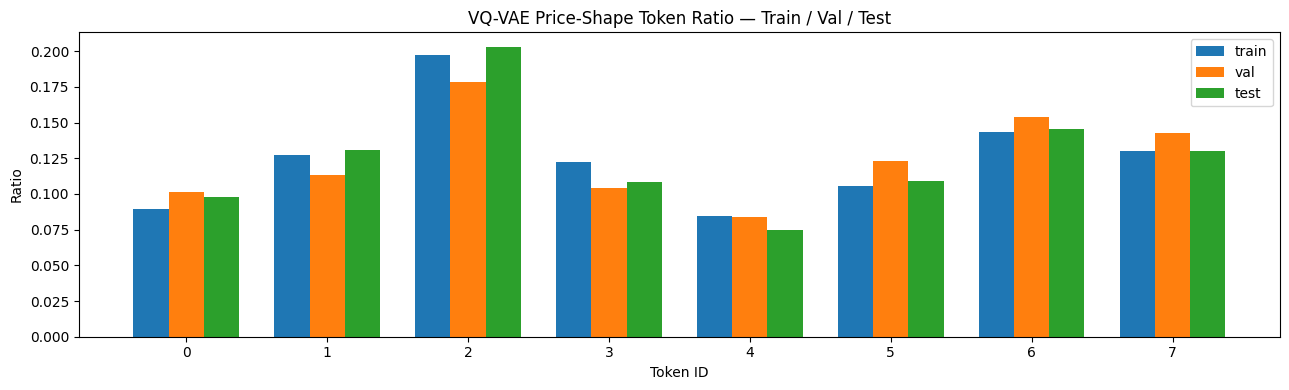

In [83]:
all_token_ids = list(range(CODEBOOK_SIZE))
width = 0.25
x = np.arange(CODEBOOK_SIZE)


def tokens_to_ratios(tokens: Sequence[int], *, k: int) -> list[float]:
    counts = np.array(tokens_to_counts(tokens, k=k), dtype=float)
    total = counts.sum()
    if total == 0:
        return [0.0 for _ in range(k)]
    return (counts / total).tolist()


plt.figure(figsize=(13, 4))
plt.bar(x - width, tokens_to_ratios(train_tokens, k=CODEBOOK_SIZE), width=width, label="train")
plt.bar(x, tokens_to_ratios(val_tokens, k=CODEBOOK_SIZE), width=width, label="val")
plt.bar(x + width, tokens_to_ratios(test_tokens, k=CODEBOOK_SIZE), width=width, label="test")
plt.title("VQ-VAE Price-Shape Token Ratio — Train / Val / Test")
plt.xlabel("Token ID")
plt.ylabel("Ratio")
plt.xticks(all_token_ids)
plt.legend()
plt.tight_layout()
save_current_figure("01_global_token_ratio_histogram.png")
plt.show()

### 10.2 Per-symbol Token Heatmap

특정 token이 특정 symbol에만 과도하게 의존하는지 확인합니다. 행은 symbol, 열은 token이며 값은 symbol 내부 정규화 비율입니다.

saved: /Users/choeseoggyu/portfolio/finlabs/research/notebooks/01_shape_quantization/runs/phase_1a_price_shape_NASDAQ_1m_k8/figures/02_per_symbol_token_heatmap.png


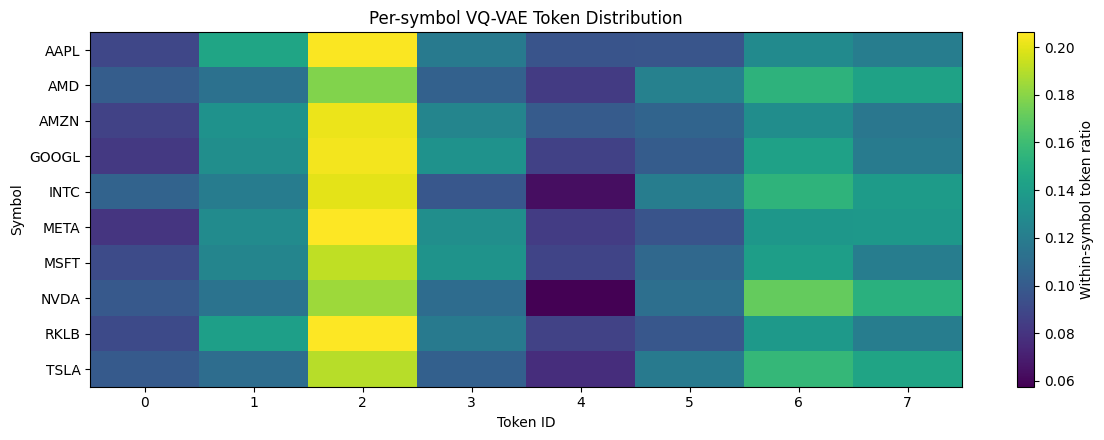

In [84]:
symbols_for_plot = sorted(per_symbol)
heatmap = np.zeros((len(symbols_for_plot), CODEBOOK_SIZE), dtype=float)

for row_index, symbol in enumerate(symbols_for_plot):
    symbol_tokens = tuple(per_symbol[symbol]["tokens"])
    counts = np.array(tokens_to_counts(symbol_tokens, k=CODEBOOK_SIZE), dtype=float)
    total = counts.sum()
    if total > 0:
        heatmap[row_index, :] = counts / total

plt.figure(figsize=(12, max(4, len(symbols_for_plot) * 0.45)))
plt.imshow(heatmap, aspect="auto", cmap="viridis")
plt.colorbar(label="Within-symbol token ratio")
plt.yticks(range(len(symbols_for_plot)), symbols_for_plot)
plt.xticks(range(CODEBOOK_SIZE), range(CODEBOOK_SIZE))
plt.title("Per-symbol VQ-VAE Token Distribution")
plt.xlabel("Token ID")
plt.ylabel("Symbol")
plt.tight_layout()
save_current_figure("02_per_symbol_token_heatmap.png")
plt.show()

### 10.3 Per-symbol Token Ratio Chart

heatmap은 전체 패턴을 보기 좋지만, token별 차이를 정량적으로 비교하기에는 막대그래프가 더 직관적입니다.

이 그림은 각 symbol 내부에서 token 사용 비율을 계산해 grouped bar chart로 표시합니다.  
특정 symbol에서만 과도하게 높거나 낮은 token이 있는지 확인합니다.

saved: /Users/choeseoggyu/portfolio/finlabs/research/notebooks/01_shape_quantization/runs/phase_1a_price_shape_NASDAQ_1m_k8/figures/03_per_symbol_token_ratio_chart.png


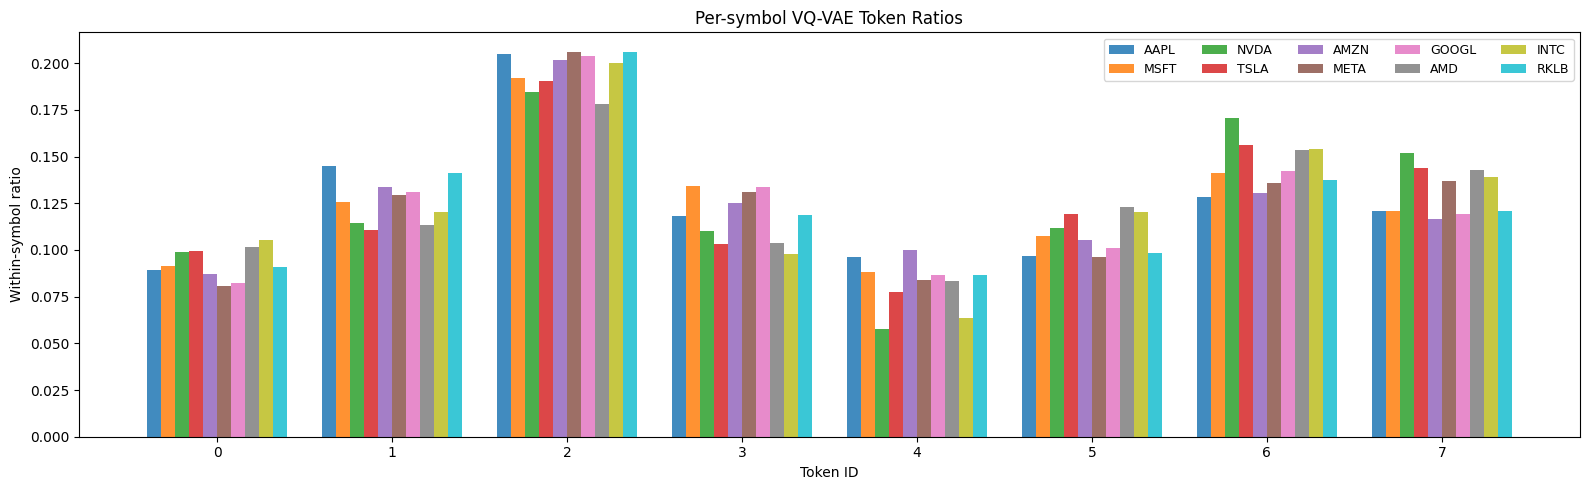

In [85]:
# Keep symbol order aligned with split semantics rather than alphabetic order.
split_ordered_symbols = train_symbols + val_symbols + test_symbols
symbols_for_ratio_chart = [symbol for symbol in split_ordered_symbols if symbol in per_symbol]
bar_width = 0.8 / max(1, len(symbols_for_ratio_chart))
x = np.arange(CODEBOOK_SIZE)

plt.figure(figsize=(16, 5))
for idx, symbol in enumerate(symbols_for_ratio_chart):
    symbol_tokens = tuple(per_symbol[symbol]["tokens"])
    ratios = tokens_to_ratios(symbol_tokens, k=CODEBOOK_SIZE)
    offset = (idx - (len(symbols_for_ratio_chart) - 1) / 2) * bar_width
    plt.bar(x + offset, ratios, width=bar_width, label=symbol, alpha=0.85)

plt.title("Per-symbol VQ-VAE Token Ratios")
plt.xlabel("Token ID")
plt.ylabel("Within-symbol ratio")
plt.xticks(range(CODEBOOK_SIZE), range(CODEBOOK_SIZE))
plt.legend(ncol=5, fontsize=9)
plt.tight_layout()
save_current_figure("03_per_symbol_token_ratio_chart.png")
plt.show()

### 10.4 Split-level Token Ratio Difference

held-out split의 token distribution이 train distribution과 얼마나 다른지 보기 위해 ratio 차이를 표시합니다.

```text
val ratio  - train ratio
test ratio - train ratio
```

0에 가까울수록 train과 held-out split의 token distribution이 유사합니다.

saved: /Users/choeseoggyu/portfolio/finlabs/research/notebooks/01_shape_quantization/runs/phase_1a_price_shape_NASDAQ_1m_k8/figures/04_split_token_ratio_difference.png


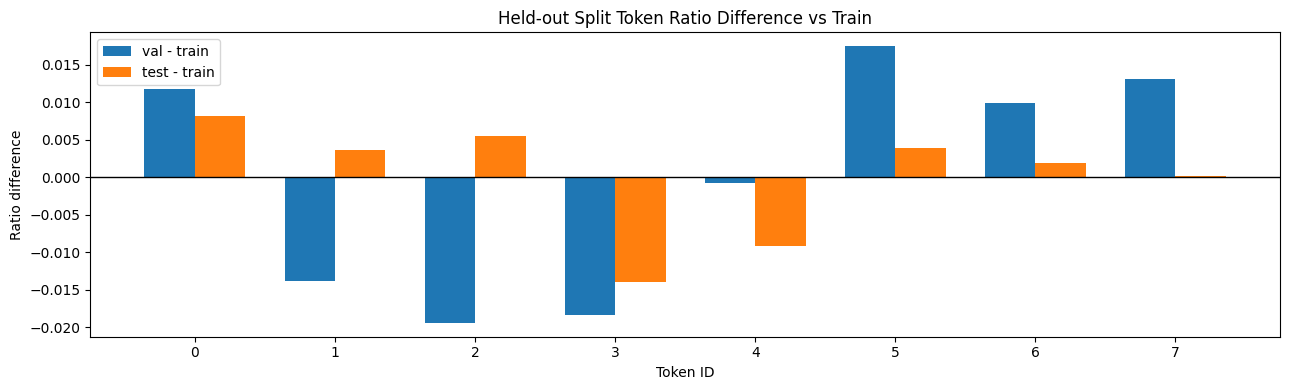

In [86]:
train_ratio = np.array(tokens_to_ratios(train_tokens, k=CODEBOOK_SIZE), dtype=float)
val_ratio = np.array(tokens_to_ratios(val_tokens, k=CODEBOOK_SIZE), dtype=float)
test_ratio = np.array(tokens_to_ratios(test_tokens, k=CODEBOOK_SIZE), dtype=float)

plt.figure(figsize=(13, 4))
plt.axhline(0.0, color="black", linewidth=1)
plt.bar(x - 0.18, val_ratio - train_ratio, width=0.36, label="val - train")
plt.bar(x + 0.18, test_ratio - train_ratio, width=0.36, label="test - train")
plt.title("Held-out Split Token Ratio Difference vs Train")
plt.xlabel("Token ID")
plt.ylabel("Ratio difference")
plt.xticks(range(CODEBOOK_SIZE), range(CODEBOOK_SIZE))
plt.legend()
plt.tight_layout()
save_current_figure("04_split_token_ratio_difference.png")
plt.show()

### 10.5 Mean Feature Heatmap by Token

token별 평균 4D price-shape feature vector를 확인합니다.

saved: /Users/choeseoggyu/portfolio/finlabs/research/notebooks/01_shape_quantization/runs/phase_1a_price_shape_NASDAQ_1m_k8/figures/05_mean_feature_heatmap.png


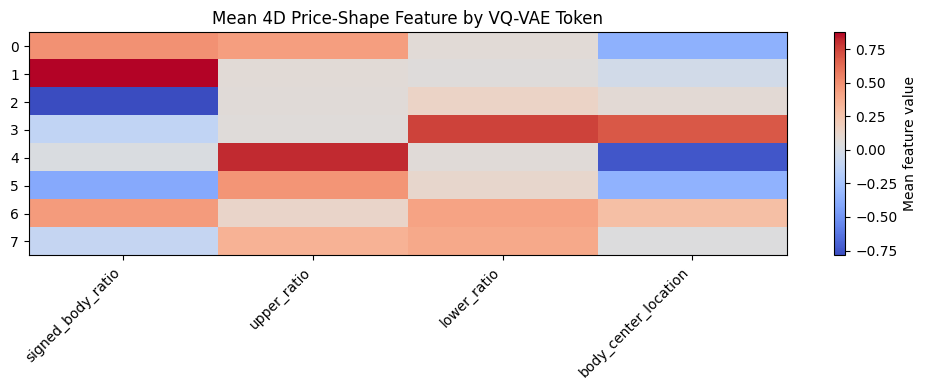

In [87]:
groups: dict[int, list[tuple[float, ...]]] = defaultdict(list)
for token, feature in zip(train_tokens, train_features, strict=True):
    groups[token].append(feature.as_tuple())

active_tokens = sorted(groups)
token_means = {
    token: np.mean(groups[token], axis=0)
    for token in active_tokens
}
matrix = np.array([token_means[token] for token in active_tokens])

plt.figure(figsize=(10, max(4, len(active_tokens) * 0.35)))
plt.imshow(matrix, aspect="auto", cmap="coolwarm")
plt.colorbar(label="Mean feature value")
plt.yticks(range(len(active_tokens)), active_tokens)
plt.xticks(range(len(FEATURE_NAMES)), FEATURE_NAMES, rotation=45, ha="right")
plt.title("Mean 4D Price-Shape Feature by VQ-VAE Token")
plt.tight_layout()
save_current_figure("05_mean_feature_heatmap.png")
plt.show()

### 10.6 Prototype Candles

자주 등장한 token의 평균 price-shape를 candle glyph로 그립니다.

saved: /Users/choeseoggyu/portfolio/finlabs/research/notebooks/01_shape_quantization/runs/phase_1a_price_shape_NASDAQ_1m_k8/figures/06_prototype_candles.png


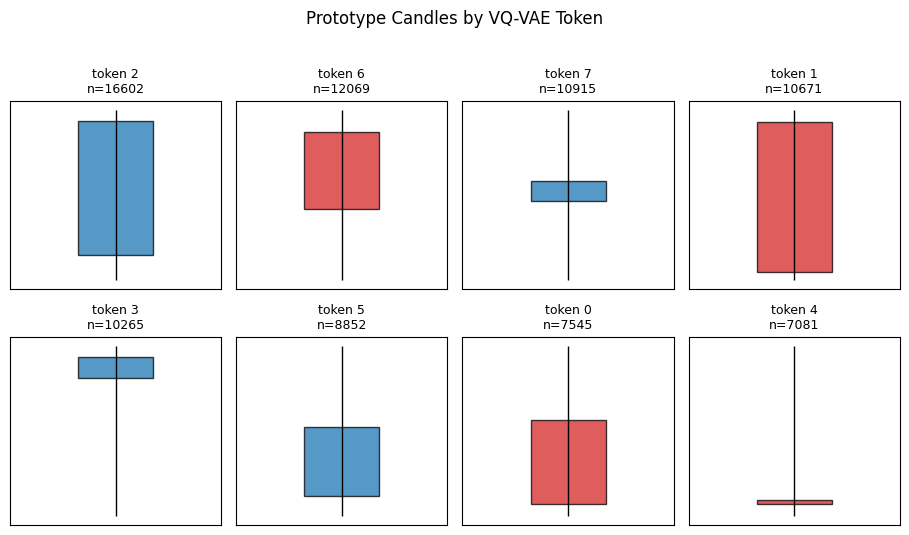

In [88]:
def draw_price_shape_prototype(ax, mean_feature, *, title: str) -> None:
    signed_body_ratio = float(mean_feature[0])
    upper_ratio = max(float(mean_feature[1]), 0.0)
    lower_ratio = max(float(mean_feature[2]), 0.0)
    body_ratio = abs(signed_body_ratio)
    direction_value = 1.0 if signed_body_ratio >= 0 else -1.0

    total = body_ratio + upper_ratio + lower_ratio
    if total <= 0:
        body_ratio = 0.02
        total = body_ratio

    body = body_ratio / total
    upper = upper_ratio / total
    lower = lower_ratio / total

    if direction_value >= 0:
        open_y = lower
        close_y = lower + body
        color = "tab:red"
    else:
        close_y = lower
        open_y = lower + body
        color = "tab:blue"

    low_y = 0.0
    high_y = lower + body + upper
    body_height = max(abs(close_y - open_y), 0.025)

    ax.vlines(0, low_y, high_y, color="black", linewidth=1)
    ax.add_patch(
        plt.Rectangle(
            (-0.16, min(open_y, close_y)),
            0.32,
            body_height,
            facecolor=color,
            edgecolor="black",
            alpha=0.75,
        )
    )
    ax.set_ylim(-0.05, 1.05)
    ax.set_xlim(-0.45, 0.45)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(title, fontsize=9)


top_tokens = [token for token, _count in Counter(train_tokens).most_common(min(12, len(active_tokens)))]
cols = 4
rows = int(np.ceil(len(top_tokens) / cols))
fig, axes = plt.subplots(rows, cols, figsize=(cols * 2.3, rows * 2.6))
axes = np.array(axes).reshape(-1)

for ax, token in zip(axes, top_tokens, strict=False):
    mean_feature = token_means[token]
    count = len(groups[token])
    draw_price_shape_prototype(ax, mean_feature, title=f"token {token}\nn={count}")

for ax in axes[len(top_tokens):]:
    ax.axis("off")

fig.suptitle("Prototype Candles by VQ-VAE Token", y=1.02)
plt.tight_layout()
save_current_figure("06_prototype_candles.png")
plt.show()

### 10.7 Feature Scatter

가장 단순한 2D projection으로 token 분리가 눈에 보이는지 확인합니다.

saved: /Users/choeseoggyu/portfolio/finlabs/research/notebooks/01_shape_quantization/runs/phase_1a_price_shape_NASDAQ_1m_k8/figures/07_feature_scatter.png


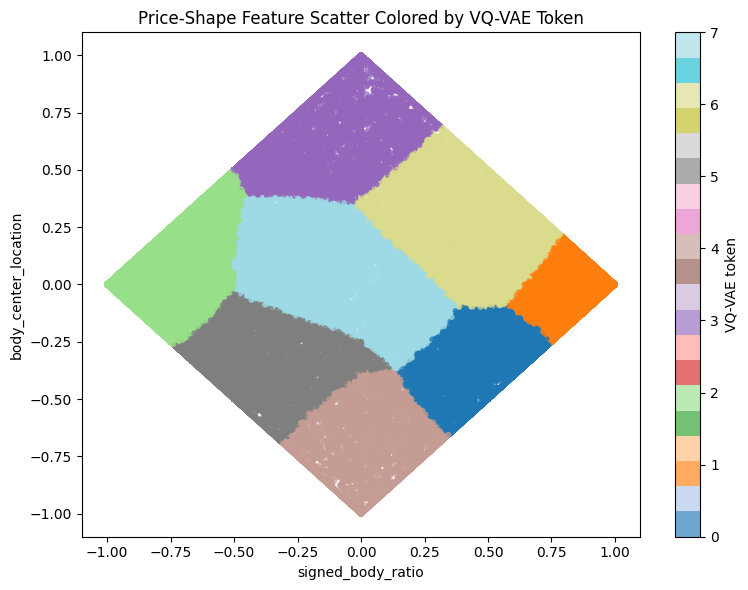

In [89]:
train_matrix = feature_matrix(train_features)

x_index = FEATURE_NAMES.index("signed_body_ratio")
y_index = FEATURE_NAMES.index("body_center_location")

plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    train_matrix[:, x_index],
    train_matrix[:, y_index],
    c=train_tokens,
    cmap="tab20",
    s=10,
    alpha=0.65,
)
plt.colorbar(scatter, label="VQ-VAE token")
plt.xlabel(FEATURE_NAMES[x_index])
plt.ylabel(FEATURE_NAMES[y_index])
plt.title("Price-Shape Feature Scatter Colored by VQ-VAE Token")
plt.tight_layout()
save_current_figure("07_feature_scatter.png")
plt.show()

### 10.8 VQ-VAE vs KMeans Distribution

동일한 codebook size에서 VQ-VAE token 분포와 KMeans cluster 분포를 비교합니다.

saved: /Users/choeseoggyu/portfolio/finlabs/research/notebooks/01_shape_quantization/runs/phase_1a_price_shape_NASDAQ_1m_k8/figures/08_vqvae_vs_kmeans_histogram.png


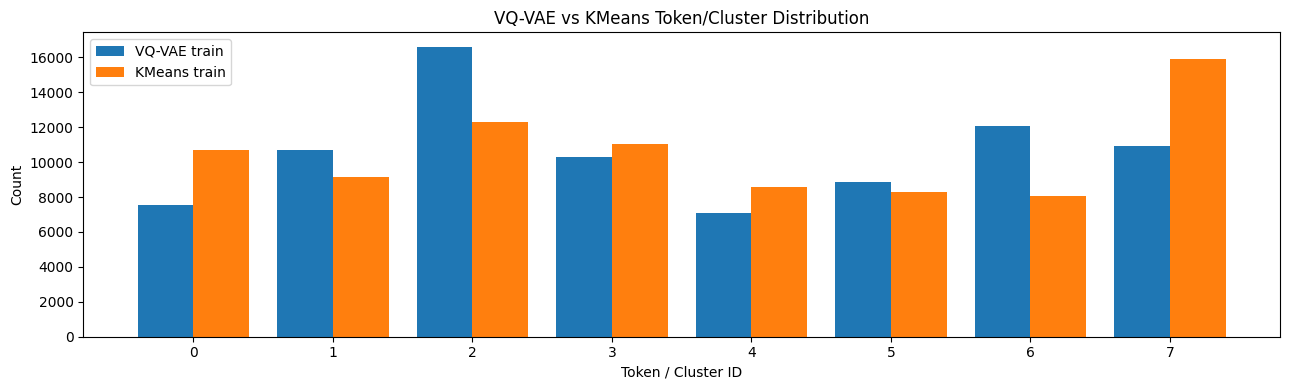

In [90]:
plt.figure(figsize=(13, 4))
plt.bar(
    x - 0.2,
    tokens_to_counts(train_tokens, k=CODEBOOK_SIZE),
    width=0.4,
    label="VQ-VAE train",
)
plt.bar(
    x + 0.2,
    tokens_to_counts(kmeans_train_tokens, k=CODEBOOK_SIZE),
    width=0.4,
    label="KMeans train",
)
plt.title("VQ-VAE vs KMeans Token/Cluster Distribution")
plt.xlabel("Token / Cluster ID")
plt.ylabel("Count")
plt.xticks(all_token_ids)
plt.legend()
plt.tight_layout()
save_current_figure("08_vqvae_vs_kmeans_histogram.png")
plt.show()

## 11. Deterministic Inference Check

같은 checkpoint와 같은 input이 같은 token sequence를 만드는지 확인합니다.

In [91]:
model_a = load_vqvae_model(result.checkpoint_path)
model_b = load_vqvae_model(result.checkpoint_path)

assert encode_features(model_a, train_features) == encode_features(model_b, train_features)
print("deterministic inference: OK")

deterministic inference: OK


## 12. Interpretation Checklist

이 notebook 결과는 다음 순서로 해석합니다.

1. VQ-VAE가 train에서 token collapse 없이 여러 token을 사용하는가?
2. val/test held-out symbol에서도 token distribution이 크게 무너지지 않는가?
3. per-symbol heatmap에서 특정 token이 특정 symbol에만 과하게 의존하지 않는가?
4. token별 평균 feature와 prototype candle이 사람이 보기에도 다른 price-shape를 나타내는가?
5. KMeans baseline과 비교했을 때 VQ-VAE를 쓸 이유가 있는가?

가능한 주장:

```text
여러 종목에서 공유되는 price-shape token vocabulary 후보를 만들었다.
```

아직 하면 안 되는 주장:

```text
market state를 발견했다.
미래 수익률을 예측한다.
매매 신호를 만들었다.
```

다음 실험 후보:

```text
K = 4, 8, 16, 32 비교
more symbols 추가
1m vs 5m vs 1d 별도 실험
Phase 1B: shape + volatility scale
Phase 1C: shape + volume context
```